<a href="https://colab.research.google.com/github/shawnfrancis578-collab/shawnfrancis578-collab.github.io/blob/main/Shawn_Practical_2_GenAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical 2: Word Embeddings Using Word2Vec

**Name:** Shawn Francis  
**Aim:** To implement Word Embeddings using Word2Vec (CBOW and Skip-gram) and compare the semantic similarity between words.

## Theory
Word embedding represents words as numerical vectors. Words used in similar contexts obtain similar vectors. Word2Vec has two architectures:

1. **CBOW (Continuous Bag of Words):** predicts a target word using its surrounding context words.
2. **Skip-gram:** predicts surrounding context words using the target word.

Cosine similarity is used to measure semantic similarity. A value closer to 1 indicates greater similarity.

In [ ]:
!pip -q install gensim matplotlib scikit-learn pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 38.0 MB/s eta 0:00:00


In [ ]:
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

print('Libraries imported successfully.')

Libraries imported successfully.


## Step 1: Prepare and preprocess the corpus

In [ ]:
corpus = [
    'the king rules the royal kingdom',
    'the queen rules the royal kingdom',
    'the king and queen live in the palace',
    'the prince lives in the royal palace',
    'the princess lives in the royal palace',
    'the king wears a golden crown',
    'the queen wears a beautiful crown',
    'apple is a sweet healthy fruit',
    'banana is a sweet healthy fruit',
    'mango is a sweet yellow fruit',
    'orange is a juicy citrus fruit',
    'people eat apple and banana',
    'people eat mango and orange',
    'a doctor works in a hospital',
    'a nurse works in a hospital',
    'a teacher works in a school',
    'a student studies in a school',
    'the doctor treats the patient',
    'the teacher teaches the student'
]

sentences = [simple_preprocess(sentence) for sentence in corpus]
for sentence in sentences:
    print(sentence)

['the', 'king', 'rules', 'the', 'royal', 'kingdom']
['the', 'queen', 'rules', 'the', 'royal', 'kingdom']
['the', 'king', 'and', 'queen', 'live', 'in', 'the', 'palace']
['the', 'prince', 'lives', 'in', 'the', 'royal', 'palace']
['the', 'princess', 'lives', 'in', 'the', 'royal', 'palace']
['the', 'king', 'wears', 'golden', 'crown']
['the', 'queen', 'wears', 'beautiful', 'crown']
['apple', 'is', 'sweet', 'healthy', 'fruit']
['banana', 'is', 'sweet', 'healthy', 'fruit']
['mango', 'is', 'sweet', 'yellow', 'fruit']
['orange', 'is', 'juicy', 'citrus', 'fruit']
['people', 'eat', 'apple', 'and', 'banana']
['people', 'eat', 'mango', 'and', 'orange']
['doctor', 'works', 'in', 'hospital']
['nurse', 'works', 'in', 'hospital']
['teacher', 'works', 'in', 'school']
['student', 'studies', 'in', 'school']
['the', 'doctor', 'treats', 'the', 'patient']
['the', 'teacher', 'teaches', 'the', 'student']


## Step 2: Train CBOW and Skip-gram models

In [ ]:
# Repetition gives the small educational corpus enough training examples.
training_data = sentences * 50

# sg=0 selects CBOW.
model_cbow = Word2Vec(
    sentences=training_data, vector_size=50, window=3,
    min_count=1, sg=0, epochs=100, workers=1, seed=42
)

# sg=1 selects Skip-gram.
model_skipgram = Word2Vec(
    sentences=training_data, vector_size=50, window=3,
    min_count=1, sg=1, epochs=100, workers=1, seed=42
)

print('CBOW model trained successfully.')
print('Skip-gram model trained successfully.')
print('Vocabulary size:', len(model_cbow.wv))

CBOW model trained successfully.
Skip-gram model trained successfully.
Vocabulary size: 41


## Step 3: Display word vectors

In [ ]:
print('CBOW vector for king (first 10 values):')
print(model_cbow.wv['king'][:10])

print('\nSkip-gram vector for king (first 10 values):')
print(model_skipgram.wv['king'][:10])

CBOW vector for king (first 10 values):
[-0.62715536  0.5965052   0.6530739   0.61707425 -0.23608078  0.186651
 -0.8412214  -0.20664321 -0.52251613 -0.06830993]

Skip-gram vector for king (first 10 values):
[-0.44675615  0.7586951   0.61156577  0.46937343 -0.25737578  0.10263472
 -0.7915174   0.01467147 -0.57866776 -0.14405464]


## Step 4: Compare semantic similarities

In [ ]:
word_pairs = [
    ('king', 'queen'),
    ('prince', 'princess'),
    ('apple', 'banana'),
    ('doctor', 'nurse'),
    ('teacher', 'student'),
    ('king', 'apple')
]

results = []
for word1, word2 in word_pairs:
    results.append({
        'Word 1': word1,
        'Word 2': word2,
        'CBOW Similarity': model_cbow.wv.similarity(word1, word2),
        'Skip-gram Similarity': model_skipgram.wv.similarity(word1, word2)
    })

similarity_table = pd.DataFrame(results)
similarity_table.round(4)

,Word 1,Word 2,CBOW Similarity,Skip-gram Similarity
0,king,queen,0.8912,0.8133
1,prince,princess,0.9983,0.9971
2,apple,banana,0.9842,0.9749
3,doctor,nurse,0.7053,0.7551
4,teacher,student,0.7301,0.7843
5,king,apple,0.2147,0.3009


## Step 5: Find words with similar meanings

In [ ]:
print('Most similar words to king using CBOW:')
for word, score in model_cbow.wv.most_similar('king', topn=5):
    print(f'{word:10s} {score:.4f}')

print('\nMost similar words to king using Skip-gram:')
for word, score in model_skipgram.wv.most_similar('king', topn=5):
    print(f'{word:10s} {score:.4f}')

Most similar words to king using CBOW:
queen      0.8912
kingdom    0.5851
beautiful  0.5758
crown      0.5716
wears      0.5162

Most similar words to king using Skip-gram:
queen      0.8133
beautiful  0.6606
crown      0.6277
kingdom    0.6148
wears      0.5532


## Step 6: Visualize word embeddings using PCA

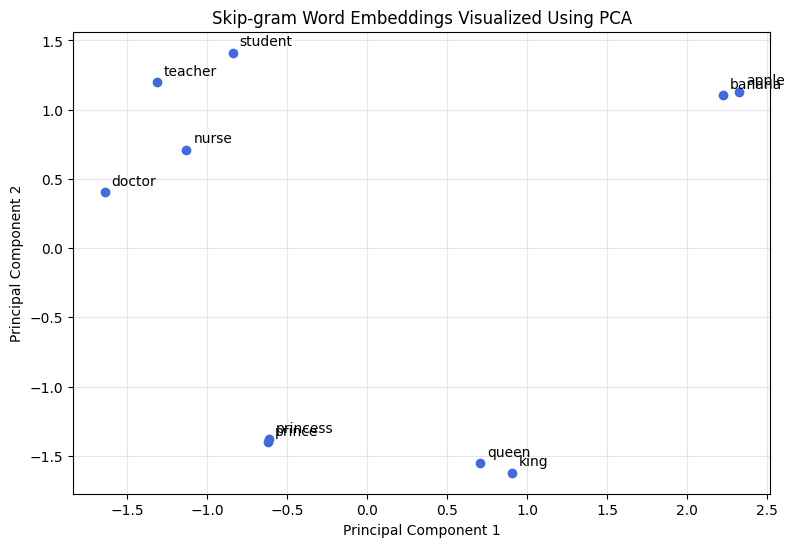

In [ ]:
words = ['king', 'queen', 'prince', 'princess', 'apple', 'banana', 'doctor', 'nurse', 'teacher', 'student']
vectors = [model_skipgram.wv[word] for word in words]
coordinates = PCA(n_components=2).fit_transform(vectors)

plt.figure(figsize=(9, 6))
plt.scatter(coordinates[:, 0], coordinates[:, 1], color='royalblue')
for index, word in enumerate(words):
    plt.annotate(word, (coordinates[index, 0], coordinates[index, 1]),
                 xytext=(5, 5), textcoords='offset points')
plt.title('Skip-gram Word Embeddings Visualized Using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(alpha=0.3)
plt.show()

## Result
Both Word2Vec models generated vector representations of the words. Cosine similarity was used to compare related and unrelated word pairs, and PCA was used to visualize selected embeddings in two dimensions.

## Conclusion
Thus, Word2Vec embeddings were successfully implemented using both CBOW and Skip-gram architectures. CBOW was selected using `sg=0`, while Skip-gram was selected using `sg=1`. The experiment demonstrated how semantic relationships between words can be measured using cosine similarity.